In [3]:
import numpy as np
import glob, re, os

def find_folders(root):
    """Map N -> path of its NMentropy_swap.txt file, from subfolders named N<N>."""
    folders = {}
    for path in glob.glob(os.path.join(root, "N*")):
        if not os.path.isdir(path):
            continue
        m = re.fullmatch(r"N(\d+)", os.path.basename(path))
        if not m:
            continue
        N = int(m.group(1))
        fpath = os.path.join(path, "NMentropy_swap.txt")
        if os.path.isfile(fpath):
            folders[N] = fpath
    return dict(sorted(folders.items()))

def load_all(root):
    files = find_folders(root)
    if not files:
        raise FileNotFoundError(f"No N<N>/NMentropy_swap.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    error = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S, err = arr[:,0], arr[:,1], arr[:,2]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
            error   = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
        error[i, :]   = err
    
    return N_values, g_ref, entropy, error

N_values, g_values, entropy, error = load_all('results/28may2026')

def f(N, g, tol=1e-6):
    """Return [entropy, error] for given N and g."""
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    return np.array([entropy[i, j], error[i, j]])

In [19]:
import numpy as np
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit

# ---------- Fit 1: S(g) at fixed N -> polynomial ----------

def fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=6):
    """
    Weighted polynomial fit of S(g) at fixed N.
    Uses numpy.polynomial.Polynomial.fit, which internally maps g onto
    [-1, 1] before fitting. This avoids the "Polyfit may be poorly
    conditioned" RankWarning that plain np.polyfit throws when g spans
    a range like [0, 5] raised to high powers (deg=6) — the raw
    Vandermonde matrix becomes badly scaled. The returned `poly` object
    is still callable directly in real g-units.
    """
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    
    g = g_values
    S = entropy[i, :]
    err = error[i, :]
    err_safe = np.where(err > 0, err, np.nanmedian(err[err > 0]))
    weights = 1.0 / err_safe
    
    poly = Polynomial.fit(g, S, deg=degree, w=weights)
    
    residuals = S - poly(g)
    chi2 = np.sum((residuals / err_safe) ** 2)
    dof = len(g) - (degree + 1)
    chi2_red = chi2 / dof
    
    return {"coeffs": poly.convert().coef, "poly": poly,
            "chi2": chi2, "chi2_red": chi2_red, "dof": dof}


def fit_all_N_poly(N_values, g_values, entropy, error, degree=6):
    """Fit S(g) polynomial for every N. Returns dict N -> fit result."""
    return {N: fit_poly_vs_g(N_values, g_values, entropy, error, N, degree)
            for N in N_values}


# ---------- Fit 2: S(N) at fixed g -> Gaussian ----------

def gaussian(N, A, mu, sigma, offset):
    return A * np.exp(-0.5 * ((N - mu) / sigma) ** 2) + offset

def fit_gaussian_vs_N(N_values, g_values, entropy, error, g, tol=1e-6):
    """
    Weighted Gaussian fit of S(N) at fixed g.
    Returns popt (A, mu, sigma, offset), pcov, and fit diagnostics.
    """
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    
    N = N_values.astype(float)
    S = entropy[:, j]
    err = error[:, j]
    err_safe = np.where(err > 0, err, np.nanmedian(err[err > 0]))
    
    # initial guesses
    A0 = S.max() - S.min()
    mu0 = N[np.argmax(S)]
    sigma0 = (N.max() - N.min()) / 4
    offset0 = S.min()
    p0 = [A0, mu0, sigma0, offset0]
    
    popt, pcov = curve_fit(gaussian, N, S, p0=p0, sigma=err_safe, absolute_sigma=True, maxfev=10000)
    
    residuals = S - gaussian(N, *popt)
    chi2 = np.sum((residuals / err_safe) ** 2)
    dof = len(N) - len(popt)
    chi2_red = chi2 / dof
    
    return {"popt": popt, "pcov": pcov, "param_names": ["A", "mu", "sigma", "offset"],
            "chi2": chi2, "chi2_red": chi2_red, "dof": dof}


def fit_all_g_gaussian(N_values, g_values, entropy, error):
    """Fit S(N) Gaussian for every g. Returns dict g -> fit result."""
    return {g: fit_gaussian_vs_N(N_values, g_values, entropy, error, g)
            for g in g_values}

In [20]:
import numpy as np
import matplotlib.pyplot as plt
# from fitting import fit_poly_vs_g, fit_gaussian_vs_N, gaussian

# ---------- Plot 1: S vs g, for specific N values ----------

def plot_S_vs_g(N_values, g_values, entropy, error, N_list, degree=6, show_fit=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    g_fine = np.linspace(g_values.min(), g_values.max(), 400)
    
    for N in N_list:
        i = np.searchsorted(N_values, N)
        assert N_values[i] == N, f"N={N} not in dataset"
        
        S = entropy[i, :]
        err = error[i, :]
        
        line = ax.errorbar(g_values, S, yerr=err, fmt='o', ms=3, capsize=2,
                            label=f"N={N} (data)", alpha=0.7)
        
        if show_fit:
            color = line[0].get_color()
            res = fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=degree)
            ax.plot(g_fine, res["poly"](g_fine), '-', color=color,
                    label=f"N={N} fit (deg={degree}, χ²ᵣ={res['chi2_red']:.2f})")
    
    ax.set_xlabel("g")
    ax.set_ylabel("Entropy S")
    ax.set_title("S vs g for fixed N")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


# ---------- Plot 2: S vs N, for specific g values ----------

def plot_S_vs_N(N_values, g_values, entropy, error, g_list, show_fit=True, ax=None, tol=1e-6):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    N_fine = np.linspace(N_values.min(), N_values.max(), 400)
    
    for g in g_list:
        j = np.argmin(np.abs(g_values - g))
        assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
        g_actual = g_values[j]
        
        S = entropy[:, j]
        err = error[:, j]
        
        line = ax.errorbar(N_values, S, yerr=err, fmt='o', ms=3, capsize=2,
                            label=f"g={g_actual:.2f} (data)", alpha=0.7)
        
        if show_fit:
            color = line[0].get_color()
            res = fit_gaussian_vs_N(N_values, g_values, entropy, error, g_actual)
            ax.plot(N_fine, gaussian(N_fine, *res["popt"]), '-', color=color,
                    label=f"g={g_actual:.2f} fit (χ²ᵣ={res['chi2_red']:.2f})")
    
    ax.set_xlabel("N")
    ax.set_ylabel("Entropy S")
    ax.set_title("S vs N for fixed g")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


# ---------- Plot 3: S(N,g) surface plot ----------

def plot_surface(N_values, g_values, entropy, cmap='viridis', elev=30, azim=-60):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    G, Nn = np.meshgrid(g_values, N_values)  # shapes match entropy (n_N, n_g)
    
    surf = ax.plot_surface(Nn, G, entropy, cmap=cmap, edgecolor='none', antialiased=True)
    
    ax.set_xlabel("N")
    ax.set_ylabel("g")
    ax.set_zlabel("Entropy S")
    ax.set_title("S(N, g) surface")
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, shrink=0.6, aspect=12, label="Entropy S")
    return ax

/home/evbdeoli/miniconda3/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/evbdeoli/miniconda3/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


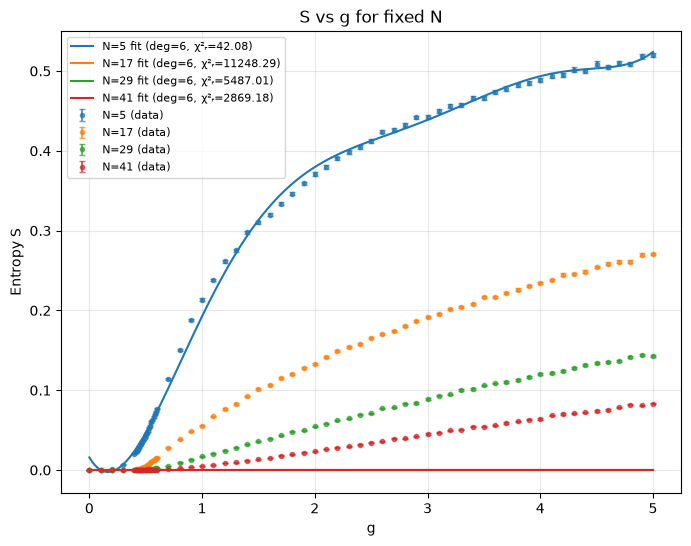

In [33]:
# S vs g for a few N values, with polynomial fits overlaid
plot_S_vs_g(N_values, g_values, entropy, error, N_list=[i for i in range(4,51) if i%2!=0][0::6], degree=6)
plt.show()

# # S vs N for a few g values, with Gaussian fits overlaid
# plot_S_vs_N(N_values, g_values, entropy, error, g_list=[g_values[10], g_values[30], g_values[50]])
# plt.show()

# # Full 3D surface
# plot_surface(N_values, g_values, entropy)
# plt.show()